# CRISPR Gene Effect: создание категорий

Чем отрицательнее `GeneEffect`, тем сильнее нокаут гена снижает выживаемость или рост клеточной модели. Значение около нуля означает, что выраженного эффекта нет.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../../../data/CRISPRGeneEffect.csv").resolve()
crispr = pd.read_csv(DATA_PATH, low_memory=False).rename(columns={"Unnamed: 0": "ModelID"})

print("Размер CRISPR-таблицы:", crispr.shape)
display(crispr.iloc[:3, :6])

Размер CRISPR-таблицы: (1208, 18532)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550)
0,ACH-000029,0.000151,0.000541,-0.046740,0.040447,-0.188685
1,ACH-000030,0.169029,-0.182773,-0.023095,0.068845,-0.037532
2,ACH-000074,-0.087069,-0.054984,0.211763,0.421891,0.013034


## Смотрим диапазон значений

Сначала изучим все доступные измерения. Для графика ограничим ось X диапазоном от `-3` до `1`, чтобы редкие экстремальные значения не сжимали основную часть распределения. Сами значения при этом из расчётов не удаляются.

count    2.149830e+07
mean    -1.492076e-01
std      4.344603e-01
min     -6.258358e+00
1%      -2.103694e+00
5%      -1.017903e+00
10%     -5.165276e-01
25%     -1.897221e-01
50%     -4.219966e-02
75%      6.533262e-02
90%      1.575418e-01
95%      2.169001e-01
99%      3.490589e-01
max      5.769172e+00
Name: GeneEffect, dtype: float64

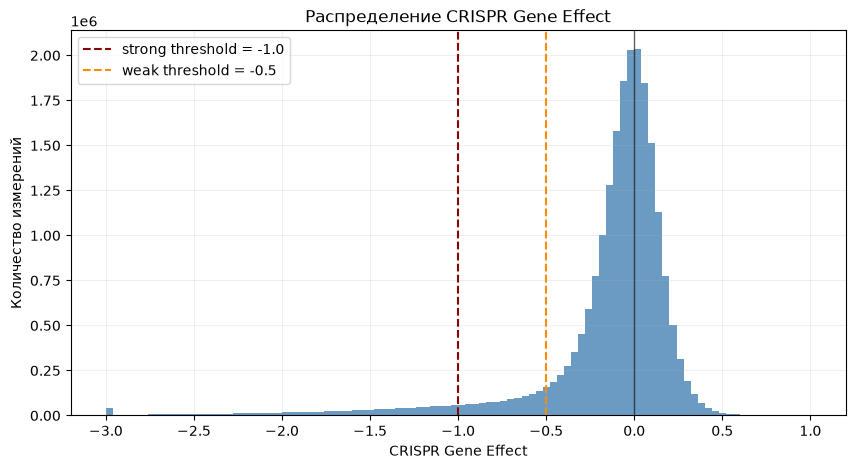

In [2]:
effect_values = pd.Series(
    crispr.drop(columns="ModelID").to_numpy().ravel(),
    name="GeneEffect",
).dropna()

display(effect_values.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(effect_values.clip(-3, 1), bins=100, color="steelblue", alpha=0.8)
ax.axvline(-1.0, color="darkred", linestyle="--", label="strong threshold = -1.0")
ax.axvline(-0.5, color="darkorange", linestyle="--", label="weak threshold = -0.5")
ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xlabel("CRISPR Gene Effect")
ax.set_ylabel("Количество измерений")
ax.set_title("Распределение CRISPR Gene Effect")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## Три категории

Используем фиксированные смысловые границы:

- `no_effect`: `GeneEffect > -0.5` — выраженной зависимости не видно;
- `weak_effect`: `-1.0 < GeneEffect <= -0.5` — нокаут умеренно снижает выживаемость или рост;
- `strong_effect`: `GeneEffect <= -1.0` — сильная зависимость клетки от работы гена.

Фиксированные пороги позволяют сравнивать разные гены между собой. Деление на тертили для каждого гена создало бы три равные группы даже у гена, нокаут которого почти ни на одну модель не влияет.

In [3]:
def create_crispr_effect_categories(
    values,
    weak_threshold=-0.5,
    strong_threshold=-1.0,
):
    return pd.cut(
        values,
        bins=[-np.inf, strong_threshold, weak_threshold, np.inf],
        labels=["strong_effect", "weak_effect", "no_effect"],
        include_lowest=True,
    )

In [4]:
effect_categories = create_crispr_effect_categories(effect_values)

category_summary = pd.DataFrame({
    "count": effect_categories.value_counts(sort=False),
    "percent": effect_categories.value_counts(normalize=True, sort=False).mul(100),
})
display(category_summary)

,count,percent
GeneEffect,,
strong_effect,1100763,5.120233
weak_effect,1111150,5.168549
no_effect,19286384,89.711218


## Пример для одного гена

Эту же функцию можно применять к таблице, которую возвращает `GeneOrchestrator`. Ниже показан пример для KRAS.

In [5]:
kras = (
    crispr[["ModelID", "KRAS (3845)"]]
    .dropna()
    .rename(columns={"KRAS (3845)": "GeneEffect"})
)
kras["EffectCategory"] = create_crispr_effect_categories(kras["GeneEffect"])

display(kras.head(10))
display(kras["EffectCategory"].value_counts(sort=False).to_frame("models"))

,ModelID,GeneEffect,EffectCategory
0,ACH-000029,-0.308262,no_effect
1,ACH-000030,-0.206455,no_effect
2,ACH-000074,-0.572546,weak_effect
3,ACH-000090,-0.648915,weak_effect
4,ACH-000093,-1.728145,strong_effect
5,ACH-000103,-0.530509,weak_effect
6,ACH-000118,-0.581449,weak_effect
7,ACH-000133,-0.814381,weak_effect
8,ACH-000155,-2.576750,strong_effect
9,ACH-000164,-2.084248,strong_effect


,models
EffectCategory,
strong_effect,219
weak_effect,414
no_effect,575


## Полный Ground Truth с категориями

Теперь преобразуем всю CRISPR-матрицу. Структура останется прежней: одна строка — один `ModelID`, один столбец — один ген. Числовой Gene Effect заменяется его категорией. Категориальный dtype хранит повторяющиеся названия экономнее, чем обычные строки.

In [6]:
def create_full_gt_dataset(
    crispr_df,
    weak_threshold=-0.5,
    strong_threshold=-1.0,
):
    gene_columns = crispr_df.columns.drop("ModelID")
    values = crispr_df[gene_columns].to_numpy()

    # Коды категорий: -1 = пропуск, 0 = strong, 1 = weak, 2 = no effect.
    category_codes = np.full(values.shape, -1, dtype=np.int8)
    category_codes[values <= strong_threshold] = 0
    category_codes[(values > strong_threshold) & (values <= weak_threshold)] = 1
    category_codes[values > weak_threshold] = 2

    labels = ["strong_effect", "weak_effect", "no_effect"]
    categorical_columns = {
        gene: pd.Categorical.from_codes(category_codes[:, index], categories=labels)
        for index, gene in enumerate(gene_columns)
    }

    gt = pd.DataFrame(categorical_columns)
    gt.insert(0, "ModelID", crispr_df["ModelID"].to_numpy())
    return gt


full_gt = create_full_gt_dataset(crispr)

print("Размер исходной CRISPR-таблицы:", crispr.shape)
print("Размер полного GT:", full_gt.shape)
display(full_gt.iloc[:5, :8])

Размер исходной CRISPR-таблицы: (1208, 18532)
Размер полного GT: (1208, 18532)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146)
0,ACH-000029,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect
1,ACH-000030,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect
2,ACH-000074,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect
3,ACH-000090,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect
4,ACH-000093,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect,no_effect


## Удаляем неинформативные гены и гены с большим количеством пропусков

Оставляем ген только при выполнении двух условий:

1. Хотя бы у `MIN_EFFECT_MODELS` моделей обнаружен `weak_effect` или `strong_effect`.
2. Доля пропущенных измерений не превышает `MAX_MISSING_FRACTION`.

По умолчанию допускаем максимум 20% пропусков, то есть для гена должны быть доступны измерения минимум у 80% из 1208 моделей. Оба порога можно менять в следующей ячейке.


In [7]:
MIN_EFFECT_MODELS = 1
MAX_MISSING_FRACTION = 0.20

gene_columns = full_gt.columns.drop("ModelID")
n_models = len(full_gt)

gene_category_summary = pd.DataFrame({
    "strong_effect": full_gt[gene_columns].eq("strong_effect").sum(),
    "weak_effect": full_gt[gene_columns].eq("weak_effect").sum(),
    "no_effect": full_gt[gene_columns].eq("no_effect").sum(),
    "missing": full_gt[gene_columns].isna().sum(),
})
gene_category_summary["measured"] = n_models - gene_category_summary["missing"]
gene_category_summary["missing_fraction"] = (
    gene_category_summary["missing"] / n_models
)
gene_category_summary["weak_or_strong"] = (
    gene_category_summary["weak_effect"]
    + gene_category_summary["strong_effect"]
)

has_effect = gene_category_summary["weak_or_strong"] >= MIN_EFFECT_MODELS
has_enough_measurements = (
    gene_category_summary["missing_fraction"] <= MAX_MISSING_FRACTION
)
genes_to_keep = gene_category_summary.index[
    has_effect & has_enough_measurements
].tolist()

filtered_gt = full_gt[["ModelID", *genes_to_keep]].copy()

print("Генов до фильтрации:", len(gene_columns))
print("Удалено генов без weak/strong effect:", int((~has_effect).sum()))
print(
    "Удалено генов с долей missing больше",
    f"{MAX_MISSING_FRACTION:.0%}:",
    int((has_effect & ~has_enough_measurements).sum()),
)
print("Генов после двух фильтров:", len(genes_to_keep))
print("Размер очищенного GT:", filtered_gt.shape)

display(
    gene_category_summary.loc[genes_to_keep]
    .sort_values("weak_or_strong", ascending=False)
    .head(10)
)


Генов до фильтрации: 18531
Удалено генов без weak/strong effect: 4406
Удалено генов с долей missing больше 20%: 314
Генов после двух фильтров: 13811
Размер очищенного GT: (1208, 13812)


,strong_effect,weak_effect,no_effect,missing,measured,missing_fraction,weak_or_strong
RPL14 (9045),1199,9,0,0,1208,0.0,1208
RPL27 (6155),1205,3,0,0,1208,0.0,1208
PSMA6 (5687),1208,0,0,0,1208,0.0,1208
RPL3 (6122),1208,0,0,0,1208,0.0,1208
PSMA7 (5688),1207,1,0,0,1208,0.0,1208
RPL31 (6160),1208,0,0,0,1208,0.0,1208
CHMP6 (79643),1191,17,0,0,1208,0.0,1208
RPL35 (11224),1157,51,0,0,1208,0.0,1208
RPL36 (25873),1199,9,0,0,1208,0.0,1208
RPL37 (6167),1205,3,0,0,1208,0.0,1208


## Насколько часто один эффект доминирует

Для каждого гена считаем, сколько категорий реально встретилось и какая категория занимает наибольшую долю среди непропущенных измерений. Это позволяет отличить универсально необходимые гены от контекстно-зависимых.


In [8]:
category_columns = ["strong_effect", "weak_effect", "no_effect"]
category_fractions = gene_category_summary[category_columns].div(
    gene_category_summary["measured"].replace(0, np.nan),
    axis=0,
)
gene_category_summary["observed_categories"] = (
    gene_category_summary[category_columns] > 0
).sum(axis=1)
gene_category_summary["dominant_category"] = category_fractions.idxmax(axis=1)
gene_category_summary["dominant_fraction"] = category_fractions.max(axis=1)

display(
    gene_category_summary["observed_categories"]
    .value_counts()
    .sort_index()
    .rename_axis("Количество присутствующих категорий")
    .to_frame("Генов")
)
display(
    gene_category_summary["dominant_category"]
    .value_counts()
    .to_frame("Генов с доминирующей категорией")
)
print("Генов только со strong_effect:", int((category_fractions["strong_effect"] == 1).sum()))
print("Генов только с no_effect:", int((category_fractions["no_effect"] == 1).sum()))


,Генов
Количество присутствующих категорий,
1,4437
2,9446
3,4648


,Генов с доминирующей категорией
dominant_category,
no_effect,16928
strong_effect,929
weak_effect,674


Генов только со strong_effect: 31
Генов только с no_effect: 4406


In [9]:
OUTPUT_PATH = DATA_PATH.parent / "CRISPRGeneEffect_GT.csv"
filtered_gt.to_csv(OUTPUT_PATH, index=False)
print("Очищенный GT сохранён:", OUTPUT_PATH)


Очищенный GT сохранён: /Users/nident/Desktop/JOB/Cancer Cell Line Encyclopedia (CCLE)/data/CRISPRGeneEffect_GT.csv


### Получение GT одного гена

Из очищенного GT можно быстро получить целевую переменную для конкретного гена.


In [10]:
def get_gene_gt(gt_df, gene):
    return (
        gt_df[["ModelID", gene]]
        .dropna()
        .rename(columns={gene: "EffectCategory"})
        .reset_index(drop=True)
    )

kras_gt = get_gene_gt(filtered_gt, "A1BG (1)")
display(kras_gt.head(10))
display(kras_gt["EffectCategory"].value_counts(sort=False).to_frame("models"))


,ModelID,EffectCategory
0,ACH-000029,no_effect
1,ACH-000030,no_effect
2,ACH-000074,no_effect
3,ACH-000090,no_effect
4,ACH-000093,no_effect
5,ACH-000103,no_effect
6,ACH-000118,no_effect
7,ACH-000133,no_effect
8,ACH-000155,no_effect
9,ACH-000164,no_effect


,models
EffectCategory,
strong_effect,0
weak_effect,1
no_effect,1207


## Возможная четвёртая категория

Позже можно отдельно выделить большие положительные значения, например `GeneEffect > 0.5`, как `growth_advantage`: после нокаута модель растёт лучше. Сейчас эту категорию не добавляем, потому что цель анализа — сила снижения выживаемости, а положительные значения встречаются редко.